Desenvolvimento de um experimento em Keras com dados estruturados (tabelas) para resolver um problema de classificação ou regressão.

1-Descrição do problema e dataset

* Explique o contexto do problema (objetivo, tipo de variável-alvo).
* Informe origem e características principais do conjunto de dados (nº de instâncias, variáveis numéricas e categóricas, presença de valores faltantes).

2-Pré-processamento

* Imputação de dados faltantes.

* Codificação de variáveis categóricas (one-hot ou embeddings).

* Escalonamento ou normalização das variáveis numéricas.

* Divisão em conjuntos de treino, validação e teste (pelo menos 70%/15%/15%).

3-Construção e treinamento do modelo

* Definição de uma rede neural densa (MLP) em Keras.

* Compilação com função de perda e métricas adequadas (por exemplo, binary_crossentropy e accuracy para classificação ou mse e mae para regressão).

* Uso de callbacks, incluindo EarlyStopping que restaure os melhores pesos.

4-Análise das curvas de aprendizagem

* Plotagem da evolução de loss de treino e de validação ao longo das épocas.

* Interpretação dos gráficos, identificando sinais de underfitting ou overfitting e justificando o ponto de parada escolhido.

5-Avaliação final e discussão

* Cálculo e apresentação das métricas no conjunto de teste.

* Discussão sobre a capacidade de generalização do modelo e possíveis melhorias (regularização, ajuste de hiperparâmetros, coleta de mais dados etc.).

6-Entrega

* Um Jupyter Notebook (.ipynb) com cada célula de código e cada bloco de texto devidamente comentados e explicados.

* Um vídeo de apresentação (máx. 15 min) em que você guia o espectador pelo notebook, destacando metodologia, resultados e conclusões.

* Observação: seu notebook deve ser autoexplicativo e permitir a reprodução completa do experimento apenas executando as células.

# Importação das bibliotecas.

In [ ]:
import pandas as pd
import numpy as np
import keras
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from tensorflow import keras
from tensorflow.keras import layers

# Parte 1: Descrição do problema e dataset

Um problema de classificação.

O data set utilizado será do titanic, em que dada uma certa configuração das caracteristicas a rede neural irá dizer se a pessoa sobrevive ou não.

A variável alvo como já dito é binária, sim ou não.

As caracteristicas das variáveis estão na célula abaixo.

Iria opatar por outro dataset como esse (https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification). Mas achei o do titanic mais "legal" de se trabalhar e aplicar o trabalho.

Neste dataset temos uma coluna "survived", que diz se aquele determinado passageiro sobreviveu ou não. Ela é a nossa variável alvo que queremos prever.

O dataset foi escolhido porque satisfaz o que foi pedido no trabalho: tem dados faltantes (ex: age) e variáveis categóricas (ex: sex, embarked), o que faz com que façamos um pré-processamento.

In [ ]:
# https://www.kaggle.com/datasets/yasserh/titanic-dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
dataset = pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Ticket class = tipo do ticket (1 = 1st, 2 = 2nd, 3 = 3rd)

SibSp = cônjugues

Parch = filhos no návio

Fare = tarifa do passageiro

embarked Port of Embarkation = Porto de embarque [C = Cherbourg, Q = Queenstown, S = Southampton]

Aqui há algumas informações adicionais sobre o dataset. (https://www.kaggle.com/c/titanic/data)

In [ ]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Parte 2: Pré processamento

Quais variáveis serão usadas para o treino e qual será usada como alvo

In [ ]:
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
TARGET = 'Survived'

Retirando as valores em que a variável alvo é nulo e também fazendo uma cópia para um novo dataset que contém apenas as variáveis que serão utilizadas.

In [ ]:
datasetAtualizado = dataset[FEATURES + [TARGET]].dropna(subset=['Embarked']).copy()

Y = datasetAtualizado[TARGET]
X = datasetAtualizado[FEATURES]

In [ ]:
datasetAtualizado.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


### Divisão do dataset(treino, validação e temporário)

O stratify garante uma proporção das classes da variável alvo seja a mesma do conjunto de teste e treinamento. Por exemplo, se 30% das pessoas no seu Y original sobreviveram, então y_treino e y_temporario também terão aproximadamente 30% de sobreviventes.

In [ ]:
X_treino, X_temporario, y_treino, y_temporario = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)
X_validacao, X_teste, y_validacao, y_teste = train_test_split(X_temporario, y_temporario, test_size=0.5, random_state=42, stratify=y_temporario)

In [ ]:
print(f"Dados para Treino: {X_treino.shape}")
print(f"Dados para Validação: {X_validacao.shape}")
print(f"Dados para Teste: {X_teste.shape}")

Dados para Treino: (622, 7)
Dados para Validação: (133, 7)
Dados para Teste: (134, 7)


In [ ]:
variaveis_numericas = ['Age', 'Fare', 'SibSp', 'Parch']
variaveis_categoricas = ['Pclass', 'Sex', 'Embarked']

In [ ]:
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, variaveis_numericas),
    ('cat', pipeline_categorico, variaveis_categoricas)])

# Parte 3: Construção e treinamento do modelo

In [ ]:
XTreinoJaProcessado = preprocessor.fit_transform(X_treino)
XvalidadoProcessado = preprocessor.transform(X_validacao)
XtesteProcessado = preprocessor.transform(X_teste)

In [ ]:
print(f"Shape Treino Processado: {XTreinoJaProcessado.shape}")
print(f"Shape Validação Processado: {XvalidadoProcessado.shape}")
print(f"Shape Teste Processado: {XtesteProcessado.shape}")

Shape Treino Processado: (622, 12)
Shape Validação Processado: (133, 12)
Shape Teste Processado: (134, 12)


Construção da rede neural(Usa o perceptron)

In [ ]:
input_shape = XTreinoJaProcessado.shape[1]

modelo = keras.Sequential([
    keras.Input(shape=(input_shape,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
#Relu -> função de ativação
#Dropout -> congelamtnto dos neurônios para evitir o overfitting
#sigmoid -> função de ativação
modelo.summary()

modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#loss='binary_crossentropy' -> função de perda
#metrics=['accuracy'] -> métrica de desempenho, acuracia pois é classificação

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Uso de callbacks, incluindo EarlyStopping que restaure os melhores pesos, como foi pedido.
earlyStopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = modelo.fit(XTreinoJaProcessado, y_treino, epochs=100, batch_size=32, validation_data=(XvalidadoProcessado, y_validacao), callbacks=[earlyStopping], verbose = 1)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6307 - loss: 0.6508 - val_accuracy: 0.6617 - val_loss: 0.5979
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6897 - loss: 0.5926 - val_accuracy: 0.7368 - val_loss: 0.5420
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7204 - loss: 0.5480 - val_accuracy: 0.8120 - val_loss: 0.4935
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7818 - loss: 0.4845 - val_accuracy: 0.8722 - val_loss: 0.4585
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7742 - loss: 0.4719 - val_accuracy: 0.8496 - val_loss: 0.4436
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8062 - loss: 0.4375 - val_accuracy: 0.8346 - val_loss: 0.4382
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7885 - loss: 0.4406 - val_accuracy: 0.8195 - val_loss: 0.4338
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7915 - loss: 0.4728 - val_accuracy: 0.8346

# Parte 4: Análise das curvas de aprendizagem

In [ ]:
history_df = history.history
loss = history_df['loss']
val_loss = history_df['val_loss']
acuracia = history_df['accuracy']
val_acuracia = history_df['val_accuracy']
epochs = range(1, len(loss) + 1)

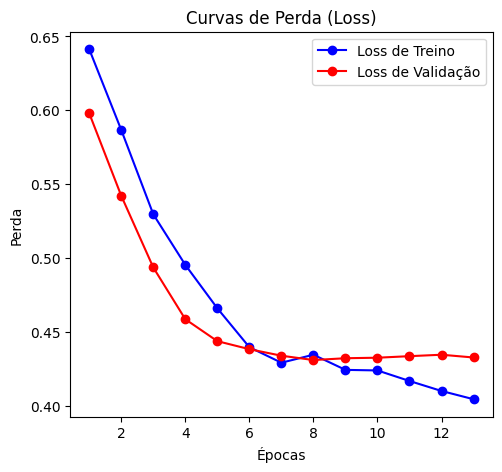

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo-', label='Loss de Treino')
plt.plot(epochs, val_loss, 'ro-', label='Loss de Validação')
plt.title('Curvas de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()

A melho época é a oitiva, pois a partir dela começa o overfitting. Por isso usamos o EalyStopping.

Curva de Treino (azul) -> Erro do treino

Curva de Validação (vermelha) -> Erro da validação

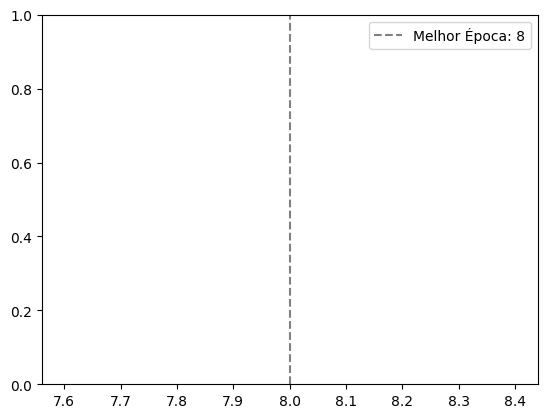

In [ ]:
melhor_epoch = np.argmin(val_loss) + 1
plt.axvline(x=melhor_epoch, color='grey', linestyle='--', label=f'Melhor Época: {melhor_epoch}')
plt.legend()

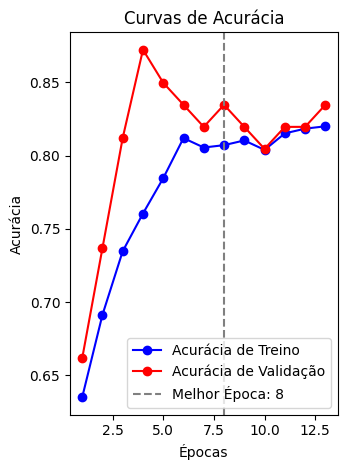

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(epochs, acuracia, 'bo-', label='Acurácia de Treino')
plt.plot(epochs, val_acuracia, 'ro-', label='Acurácia de Validação')
plt.title('Curvas de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')

plt.axvline(x=melhor_epoch, color='grey', linestyle='--', label=f'Melhor Época: {melhor_epoch}')
plt.legend()

plt.tight_layout()
plt.show()

O modelo atingiu sua melhor acurácia na época 4, mas como estávamos monitorando a perda, o EarlyStopping escolheu a época 8 como o ponto de parada oficial. Isso é muito comum, já que a perda (loss) é uma métrica mais estável para o otimizador do que a acurácia.

# Parte 5: Avaliação final e discussão

In [ ]:
results = modelo.evaluate(XtesteProcessado, y_teste, verbose=0)

test_loss = results[0]
test_accuracy = results[1]

print(f"\nResultados no Conjunto de Teste:")
print(f"  Perda (Loss) de Teste: {test_loss:.4f}")
print(f"  Acurácia de Teste: {test_accuracy * 100:.2f}%")

best_val_accuracy = max(history.history['val_accuracy'])
print(f"  Melhor Acurácia na Validação: {best_val_accuracy * 100:.2f}%")


Resultados no Conjunto de Teste:
  Perda (Loss) de Teste: 0.4553
  Acurácia de Teste: 82.84%
  Melhor Acurácia na Validação: 87.22%


In [ ]:
X_para_prever = XtesteProcessado

raw_predictions = modelo.predict(X_para_prever)

final_predictions = (raw_predictions > 0.5).astype(int)
final_predictions1 = (raw_predictions > 0.5)

print("--- Comparando Previsão vs. Real ---")
print("Previsão do Modelo:", final_predictions.flatten())
print("Gabarito (Real):   ", y_teste.values)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
--- Comparando Previsão vs. Real ---
Previsão do Modelo: [1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1]
Gabarito (Real):    [1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0
 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 1 0 0 1 0 0
 0 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 0 0 0 0
 0 0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0]


In [ ]:
print("\n--- Iniciando Previsões no Conjunto de Teste ---")
# Como usamos a sigmoid
raw_predictions = modelo.predict(XtesteProcessado)

# 2. Converter probabilidades em classes (0 ou 1)
# Como usamos a sigmoid e o nosso limite(threshole é 0.5), temos que (<= 0.5 morreu e o modelo prevê 0),(> 0.5 sobreviveu e o modelo prevê 1)
final_predictions = (raw_predictions > 0.5).astype(int)

print("\n--- Comparação: Previsão vs. Real ---")

df_comparacao = pd.DataFrame({'Previsão do Modelo': final_predictions.flatten(),'Valor Real (Gabarito)': y_teste.values,'Probabilidade Crua': raw_predictions.flatten()})

# Adiciona uma coluna para ver se acertou
df_comparacao['Acertou?'] = df_comparacao['Previsão do Modelo'] == df_comparacao['Valor Real (Gabarito)']

print(df_comparacao.head(20))

print("\n--- Resumo dos Acertos ---")
total_acertos = df_comparacao['Acertou?'].sum()
total_amostras = len(df_comparacao)
print(f"O modelo acertou {total_acertos} de {total_amostras} passageiros.")

print(f"Acurácia : {total_acertos / total_amostras * 100:.2f}%")


--- Iniciando Previsões no Conjunto de Teste ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 

--- Comparação: Previsão vs. Real ---
    Previsão do Modelo  Valor Real (Gabarito)  Probabilidade Crua  Acertou?
0                    1                      1            0.515913      True
1                    0                      0            0.256699      True
2                    0                      0            0.146932      True
3                    0                      0            0.115985      True
4                    0                      0            0.111382      True
5                    0                      0            0.115985      True
6                    0                      1            0.266531     False
7                    0                      0            0.405516      True
8                    1                      1            0.761873      True
9                    1                      1            0.883158      True
10                   0              